In [1]:
import sys, pickle
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt

here = Path.cwd()
for p in [here, *here.parents]:
    if (p / "utils.py").exists():
        sys.path.insert(0, str(p)); REPO = p; break
import utils
utils.frontiers_style()

cache = REPO / "cache"
with open(cache / "meta.pkl", "rb") as f:
    meta = pickle.load(f)
file_names   = meta["file_names"]
problem_type = meta["problem_type"]
scores       = meta["scores"]
with open(cache / "out_agg.pkl", "rb") as f:
    out_agg = pickle.load(f)

basic_info = utils.load_basic_info()
clf, reg = utils.split_problem_lists(file_names, basic_info)
print(f"loaded: {len(file_names)} tasks | {len(clf)} clf | {len(reg)} reg | out_agg for {len(out_agg)} tasks")

loaded: 31 tasks | 14 clf | 17 reg | out_agg for 31 tasks


In [3]:
# ===================== F4 — frames + sanity (NaN-safe) =====================
M1     = {'clf': 'mean_accuracy', 'reg': 'mean_MAE'}
BETTER = {'clf': 'high',          'reg': 'low'}

def pooled_test(tasks, ycol):
    keep = ['algorithm', 'combo_id', 'outer_k', 'iteration', 'default_config', ycol]
    return pd.concat([out_agg[t][out_agg[t].fold == 'test'][keep].assign(task=t) for t in tasks],
                     ignore_index=True)

merged, best, defrank, summary, failrate = {}, {}, {}, {}, {}
for kind, tasks in [('clf', clf), ('reg', reg)]:
    yc, hi = M1[kind], (BETTER[kind] == 'high')
    base = pooled_test(tasks, yc)

    # (A) FAILURE RATE = % of runs with NaN metric (model produced no valid score) — separate risk axis
    failrate[kind] = base.groupby('algorithm')[yc].apply(lambda s: 100 * s.isna().mean())

    # (B) performance panels on VALID runs only
    v = base.dropna(subset=[yc]).copy()
    d = (v[v.default_config == 'default']
         .rename(columns={yc: 'default_val'})[['task','outer_k','iteration','algorithm','default_val']])
    assert not d.duplicated(['task','outer_k','iteration','algorithm']).any(), "duplicate default!"
    m = v.merge(d, on=['task','outer_k','iteration','algorithm'], how='left')
    n_nodef = int(m['default_val'].isna().sum())           # valid configs whose default failed -> can't ratio
    m = m.dropna(subset=['default_val']).copy()
    m['ratio'] = m[yc] / m['default_val']
    merged[kind] = m
    print(f"[{kind}] {len(base)} runs | {int(base[yc].isna().sum())} NaN-metric dropped "
          f"| {n_nodef} valid configs dropped (their default failed)")

    # Panel 1: rank valid defaults within each (task,k,iter); 1 = best
    dd = v[v.default_config == 'default'].copy()
    dd['rank'] = dd.groupby(['task','outer_k','iteration'])[yc].rank(method='min', ascending=not hi)
    defrank[kind] = dd
    # Panel 2: best-case tuning ratio per (task,k,iter,algo)
    g = m.groupby(['task','outer_k','iteration','algorithm'])['ratio']
    b = (g.max() if hi else g.min()).reset_index(name='best_ratio'); best[kind] = b
    if hi: assert b['best_ratio'].min() > 0.999
    else:  assert b['best_ratio'].max() < 1.001
    # Panel 3: %-worse among valid alt configs
    alt = m[m.default_config == 'alt']
    worse = (alt['ratio'] < 1) if hi else (alt['ratio'] > 1)
    pw = worse.groupby(alt['algorithm']).mean() * 100

    summary[kind] = pd.DataFrame({
        'fail_rate_%':     failrate[kind],
        'def_rank_med':    dd.groupby('algorithm')['rank'].median(),
        'best_ratio_med':  b.groupby('algorithm')['best_ratio'].median(),
        'best_ratio_mean': b.groupby('algorithm')['best_ratio'].mean(),
        'pct_worse':       pw,
    }).round(3)
    print(f"\n===== {kind} =====\n", summary[kind].to_string(), "\n")

avg_rank = ((summary['clf']['def_rank_med'] + summary['reg']['def_rank_med']) / 2).sort_values()
ALGO_ORDER = list(avg_rank.index)
print("ALGO_ORDER (robust -> fragile):", ALGO_ORDER)

[clf] 78960 runs | 0 NaN-metric dropped | 0 valid configs dropped (their default failed)

===== clf =====
            fail_rate_%  def_rank_med  best_ratio_med  best_ratio_mean  pct_worse
algorithm                                                                       
GB                 0.0           2.0           1.013            1.022     58.598
GP                 0.0           3.0           1.011            1.042     50.476
KNN                0.0           4.0           1.035            1.059     50.369
LR                 0.0           7.0           1.214            1.267     35.768
MLP                0.0           5.0           1.150            1.150     44.529
RF                 0.0           2.0           1.011            1.018     67.018
SVM                0.0           5.0           1.108            1.127     66.136 

[reg] 84150 runs | 4078 NaN-metric dropped | 546 valid configs dropped (their default failed)

===== reg =====
            fail_rate_%  def_rank_med  best_ratio_m

C:\Users\conno\AppData\Local\Temp\ipykernel_16692\2211714725.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


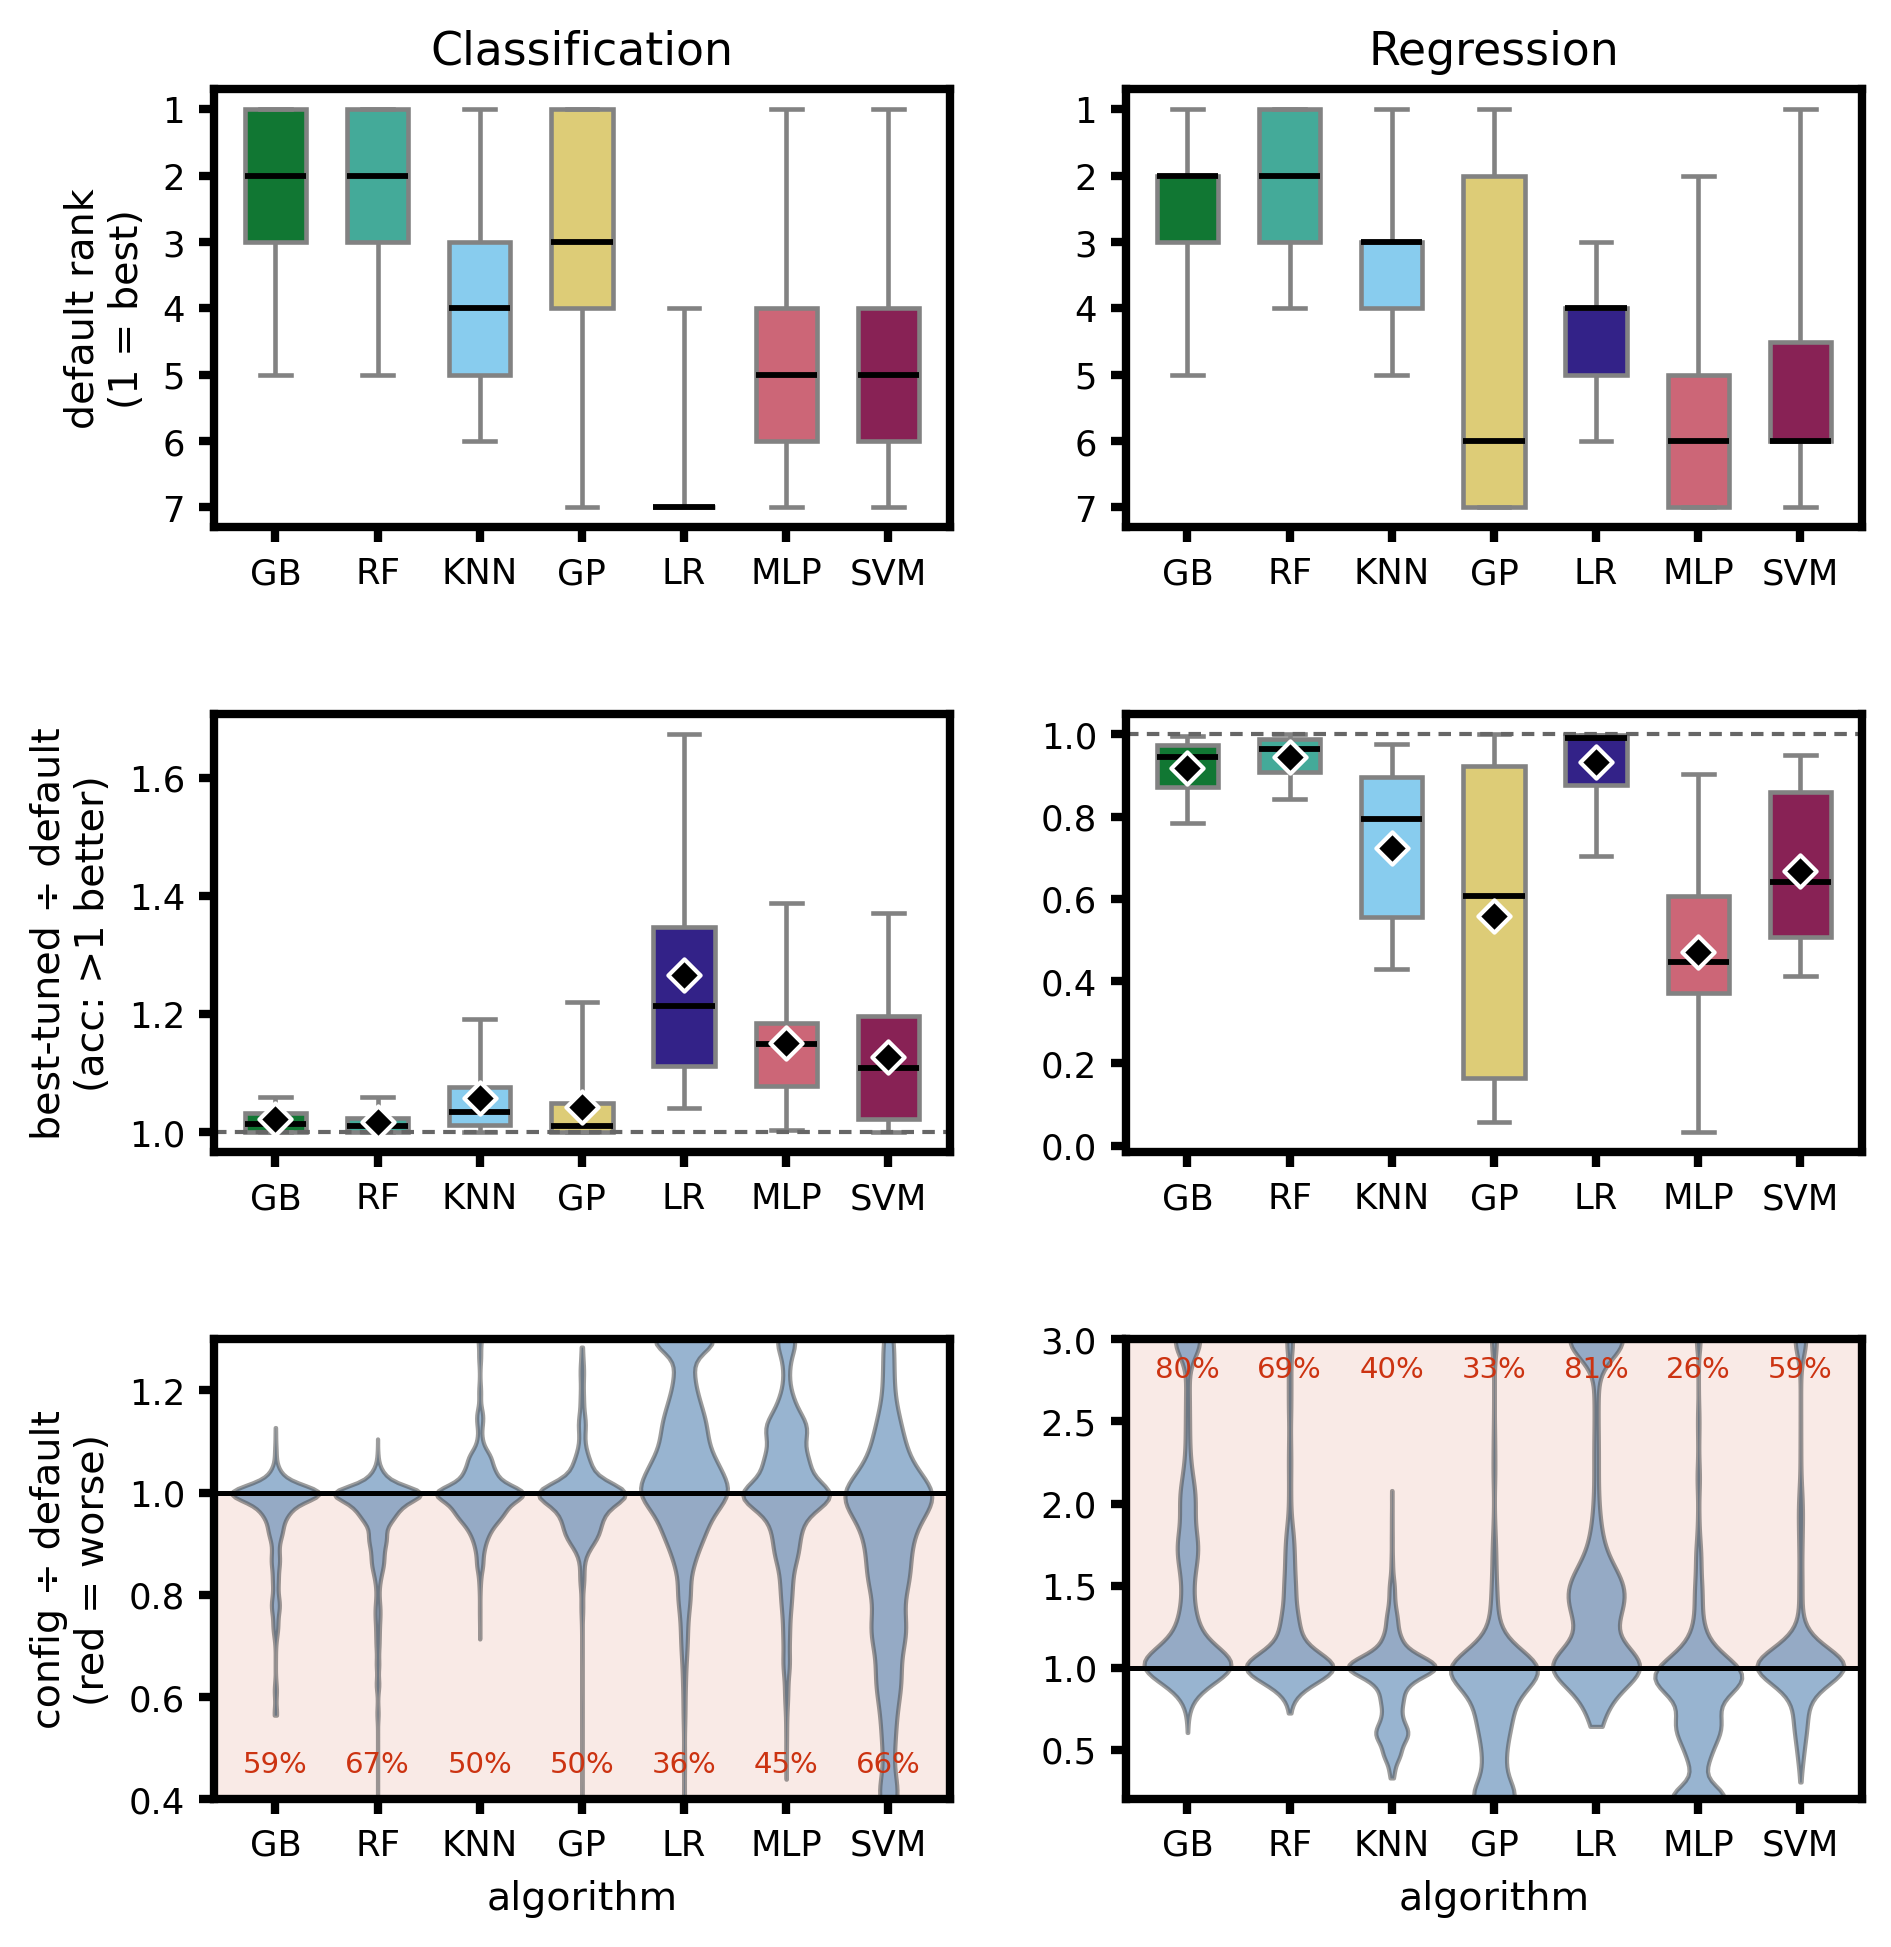

In [5]:
# ===================== F4 — figure (3x2, no failure lane) =====================
import seaborn as sns
import matplotlib.gridspec as gridspec
plt.rcParams.update({
    'axes.linewidth': 2.0, 'font.size': 9, 'axes.titlesize': 11, 'axes.labelsize': 9.5,
    'xtick.labelsize': 8.5, 'ytick.labelsize': 8.5, 'xtick.major.width': 2.0, 'ytick.major.width': 2.0,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})
ALGO_PAL = dict(zip(ALGO_ORDER, ['#117733','#44AA99','#88CCEE','#DDCC77','#332288','#CC6677','#882255']))
RED = '#CC3311'
KINDS = [('clf','Classification'), ('reg','Regression')]

def style_x(ax, xlabel=False):
    ax.set_xticks(range(len(ALGO_ORDER)))
    ax.set_xticklabels(ALGO_ORDER)                      # algo IDs on EVERY panel
    ax.set_xlim(-0.6, len(ALGO_ORDER)-0.4)
    ax.set_xlabel('algorithm' if xlabel else '')

fig = plt.figure(figsize=(180/25.4, 188/25.4))
gs = gridspec.GridSpec(3, 2, height_ratios=[1, 1, 1.05], hspace=0.42, wspace=0.24)

for ci, (kind, ctitle) in enumerate(KINDS):
    hi = (BETTER[kind] == 'high')

    # row 0 — default algorithm baseline (rank; 1 = best, on top)
    ax1 = fig.add_subplot(gs[0, ci])
    sns.boxplot(data=defrank[kind], x='algorithm', y='rank', order=ALGO_ORDER, ax=ax1,
                whis=(5,95), showfliers=False, width=0.6, color='0.85',
                linewidth=1.1, medianprops=dict(color='black', lw=1.4))
    for p, a in zip(ax1.patches, ALGO_ORDER): p.set_facecolor(ALGO_PAL[a])
    ax1.invert_yaxis(); ax1.set_yticks([1,2,3,4,5,6,7]); style_x(ax1, False)
    ax1.set_title(ctitle, fontsize=11, pad=6)
    ax1.set_ylabel('default rank\n(1 = best)') if ci == 0 else ax1.set_ylabel('')

    # row 1 — best-case tuning benefit (best-tuned ÷ default); box=median, diamond=mean
    ax2 = fig.add_subplot(gs[1, ci])
    sns.boxplot(data=best[kind], x='algorithm', y='best_ratio', order=ALGO_ORDER, ax=ax2,
                whis=(5,95), showfliers=False, width=0.6, color='0.85',
                linewidth=1.1, medianprops=dict(color='black', lw=1.4))
    for p, a in zip(ax2.patches, ALGO_ORDER): p.set_facecolor(ALGO_PAL[a])
    means = best[kind].groupby('algorithm')['best_ratio'].mean().reindex(ALGO_ORDER)
    ax2.scatter(range(len(ALGO_ORDER)), means.values, marker='D', s=30, color='black',
                edgecolor='white', lw=1.0, zorder=10)
    ax2.axhline(1.0, color='0.4', lw=1.0, ls=(0,(3,2)))
    ax2.set_ylabel('best-tuned ÷ default\n(acc: >1 better)' if hi else
                   'best-tuned ÷ default\n(MAE: <1 better)') if ci == 0 else ax2.set_ylabel('')
    style_x(ax2, False)

    # row 2 — downside risk: config ÷ default distribution, worse-than-default region shaded red
    ax3 = fig.add_subplot(gs[2, ci])
    alt = merged[kind][merged[kind].default_config == 'alt']
    ylim = (0.4, 1.3) if hi else (0.2, 3.0)
    data = [np.clip(alt[alt.algorithm == a]['ratio'].values, *ylim) for a in ALGO_ORDER]
    parts = ax3.violinplot(data, positions=range(len(ALGO_ORDER)), widths=0.85, showextrema=False)
    for b in parts['bodies']: b.set_facecolor('#4477AA'); b.set_alpha(0.55); b.set_edgecolor('0.3')
    (ax3.axhspan(ylim[0], 1.0, color=RED, alpha=0.10, zorder=0) if hi else
     ax3.axhspan(1.0, ylim[1], color=RED, alpha=0.10, zorder=0))
    ax3.axhline(1.0, color='black', lw=1.2, zorder=5)
    worse = (alt['ratio'] < 1) if hi else (alt['ratio'] > 1)
    pw = (worse.groupby(alt['algorithm']).mean()*100).reindex(ALGO_ORDER)
    ytxt, va = (ylim[0]+0.04, 'bottom') if hi else (ylim[1]-0.1, 'top')
    for i, a in enumerate(ALGO_ORDER):
        ax3.text(i, ytxt, f"{pw[a]:.0f}%", ha='center', va=va, fontsize=7, color=RED)
    ax3.set_ylim(*ylim); style_x(ax3, True)
    ax3.set_ylabel('config ÷ default\n(red = worse)') if ci == 0 else ax3.set_ylabel('')

fig.tight_layout()

In [6]:
from pathlib import Path
figdir = REPO / "figures"; figdir.mkdir(exist_ok=True)
fig.savefig(figdir / "Figure4_tuning.pdf", dpi=300, bbox_inches='tight')
fig.savefig(figdir / "Figure4_tuning.png", dpi=300, bbox_inches='tight')  # for quick viewing
print("saved to", figdir)

saved to C:\Users\conno\Documents\GitHub\ML_MetaLearning_SoftMatter\figures
